# Getting started with MemsArrayDB objects

The `MemsArrayDB` class allows getting signals from MemsArray saved in a remote database 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from megamicros.log import log
from megamicros.core.db import MemsArrayDB

log.setLevel( "INFO" )

# Set database access credentials
DBHOST = 'http://dbwelfare.biimea.io/'
LOGIN = 'ailab'
EMAIL = 'bruno.gas@biimea.com'
PASSWORD = '#T;uZnQ5UJ_JC~&'

## Starting with simple signals

One has only to specify the file identifier.

The ``MemsArrayDB`` constructor connects to the database and populates the antenna parameters with metadata received from the database. An exception is raised if connection failed.

In [2]:
# Choose the very first signal file of the database-
FILE_ID = 10

# Define the antenna
antenna = MemsArrayDB( 
    dbhost=DBHOST, login=LOGIN, email=EMAIL, password=PASSWORD, 
    file_id=FILE_ID
)

2023-10-05 18:03:51,781 [INFO]:  .Install MemsArrayDB settings
2023-10-05 18:03:51,782 [INFO]:  .Created a new antenna
2023-10-05 18:03:51,784 [INFO]:  .Install MemsArrayDB settings
2023-10-05 18:03:51,785 [INFO]:  .Try connecting on endpoint database http://dbwelfare.biimea.io/...
2023-10-05 18:03:52,188 [INFO]:  .Got HTTP 200 status code from server
2023-10-05 18:03:52,190 [INFO]:  .Received CSRF token: RAvRZIofaDHLih24v6vjWxgv79xlCa2g. Update session with
2023-10-05 18:03:52,191 [INFO]:  .Received session id: qf43r8xx0oavhu421fwnyjeixk2h9odm
2023-10-05 18:03:52,192 [INFO]:  .Successfully connected on http://dbwelfare.biimea.io/
2023-10-05 18:03:52,193 [INFO]:  .Downloading metadata for object 'sourcefile' [10]...
2023-10-05 18:03:52,194 [INFO]:  .Send a database request on endpoint: http://dbwelfare.biimea.io//sourcefile/10
2023-10-05 18:03:52,255 [INFO]:  .Object sourcefile found with identifier [10] 
2023-10-05 18:03:52,256 [INFO]:  .Set 32 available MEMs numbered from 0 to 31
202

You can get now some Meta informations regarding the file

In [3]:
print( f"Sampling frequency: {antenna.sampling_frequency}Hz" )
print( f"Available MEMs number: {antenna.available_mems_number}" )
print( f"Whether counter is available or not: {antenna.counter}" )

Sampling frequency: 10000.0Hz
Available MEMs number: 32
Whether counter is available or not: True


## Getting and plotting some MEMs signals

You can select some MEMs you would like to plot and get signals on a given range time (10 seconds in thois example)

In [4]:
# Run antenna
antenna.run(
    mems = [0, 1, 2, 3, 4, 5, 6],
    duration=10,
    counter_skip = True,
    datatype='float32'
)

# Init a np.ndarray
signals = np.ndarray( (0, antenna.channels_number ) )

# Get signals
for data in antenna:
    signals = np.concatenate( ( signals, data ), axis=0 )

# waiting for the end of the running thread is mandatory
antenna.wait()
print( f"exit from loop. Signal shape is: {np.shape( signals )}" )

2023-10-05 18:04:07,294 [INFO]:  .Starting run execution
2023-10-05 18:04:07,295 [INFO]:  .Install MemsArray.run() settings
2023-10-05 18:04:07,297 [INFO]:  .7 MEMs were activated among 0 to 31 available MEMs
2023-10-05 18:04:07,298 [INFO]:  .Set datatype to float32 
2023-10-05 18:04:07,299 [INFO]:  .Install MemsArrayDB settings
2023-10-05 18:04:07,300 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-10-05 18:04:07,301 [INFO]:  .Pre-execution checks for MemsArrayDB.run()
2023-10-05 18:04:07,302 [INFO]:  .Perform a 10s run loop
2023-10-05 18:04:07,302 [INFO]:  .Frame length: 256 samples (chunk size: 5120 Bytes)
2023-10-05 18:04:07,303 [INFO]:  .Sampling frequency: 10000.0 Hz
2023-10-05 18:04:07,304 [INFO]:  .Active MEMs: [0, 1, 2, 3, 4, 5, 6]
2023-10-05 18:04:07,305 [INFO]:  .Active analogic channels: []
2023-10-05 18:04:07,305 [INFO]:  .Whether counter is active: True
2023-10-05 18:04:07,306 [INFO]:  .Skipping counter: True
2023-10-05 18:04:07,307 [INFO]:  .Starting duration tim

exit from loop. Signal shape is: (79505, 7)


2023-10-05 18:04:17,309 [INFO]:  .End of timer thread


Here is the ploting program

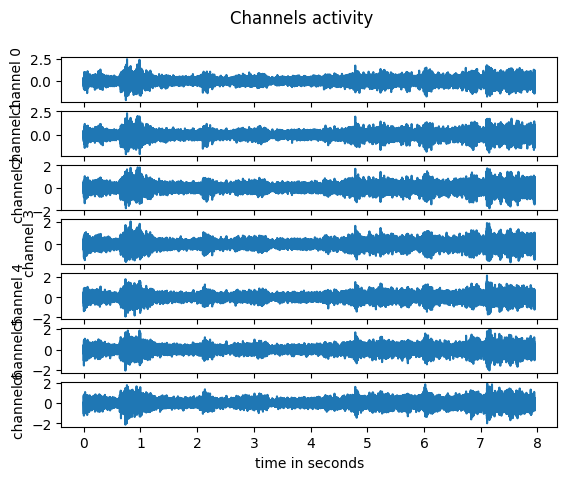

In [5]:
# plot signals
time = np.array( range( np.size(signals,0) ) )/antenna.sampling_frequency
fig, axs = plt.subplots( antenna.channels_number )
fig.suptitle('Channels activity')	
for s in range( antenna.channels_number ):
    axs[s].plot( time, signals[:,s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()

## Saving signals as wave file
TO BE REVIEWED !!!

In [10]:
import wave

WAV_FILENAME = 'titi.wav'

# 2 seconds run, getting signals from MEMs 1 and 2
antenna.run(
    mems = [5, 6],
    duration=5,
    counter_skip = True,
    datatype='int32'
)

with  wave.open( WAV_FILENAME, mode='wb' ) as wavfile:
    wavfile.setnchannels(2)
    wavfile.setsampwidth(2)
    wavfile.setframerate( antenna.sampling_frequency )

    # Get signals
    for data in antenna:
        signal = data >> 4
        wavfile.writeframesraw( np.int16( np.reshape( signal, np.size( signal ), order='F' ) ) )

# waiting for the end of the running thread is mandatory
antenna.wait()

2023-10-05 18:09:22,829 [INFO]:  .Starting run execution
2023-10-05 18:09:22,832 [INFO]:  .Install MemsArray.run() settings
2023-10-05 18:09:22,834 [INFO]:  .2 MEMs were activated among 0 to 31 available MEMs
2023-10-05 18:09:22,835 [INFO]:  .Set datatype to int32 
2023-10-05 18:09:22,837 [INFO]:  .Install MemsArrayDB settings
2023-10-05 18:09:22,838 [INFO]:  .Pre-execution checks for MemsArray.run()
2023-10-05 18:09:22,838 [INFO]:  .Pre-execution checks for MemsArrayDB.run()
2023-10-05 18:09:22,839 [INFO]:  .Perform a 5s run loop
2023-10-05 18:09:22,839 [INFO]:  .Frame length: 256 samples (chunk size: 5120 Bytes)
2023-10-05 18:09:22,840 [INFO]:  .Sampling frequency: 10000.0 Hz
2023-10-05 18:09:22,841 [INFO]:  .Active MEMs: [5, 6]
2023-10-05 18:09:22,842 [INFO]:  .Active analogic channels: []
2023-10-05 18:09:22,843 [INFO]:  .Whether counter is active: True
2023-10-05 18:09:22,844 [INFO]:  .Skipping counter: True
2023-10-05 18:09:22,845 [INFO]:  .Starting duration timer for 5s running 

## Getting labelized signals

You can obtain labelled signals from the base by specifying the necessary parameters: 
* The label identifier
* The file identifier where labeled signals are
* The sequence identifier 

In [ ]:
# choose label, file and sequence in file:
LABEL_ID = 18
FILE_ID = 8692          # 5838 (1), 7135 (1), 6860(3), 6560(1)
SEQUENCE_ID = 0  

# Define the antenna
antenna = MemsArrayDB( 
    dbhost=DBHOST, login=LOGIN, email=EMAIL, password=PASSWORD, 
    label_id=LABEL_ID, file_id=FILE_ID, sequence_id=SEQUENCE_ID
)

## Running

In [ ]:
# 2 seconds run, getting signals from MEMs 1 and 2

antenna.run(
    mems = [0, 1, 2, 3, 4, 5, 6],
    duration=10,
    buffer_length=512,
    signal_q_size = 0,
    counter_skip = True,
    datatype='float32'
)

signals = np.ndarray( (0, antenna.channels_number ) )

for data in antenna:
    signals = np.concatenate( ( signals, data ), axis=0 )

print( f"exit from loop, signal shape is: {np.shape( signals )}" )

# waiting for the end of the running thread is mandatory
antenna.wait()

# plot signals
time = np.array( range( np.size(signals,0) ) )/antenna.sampling_frequency
fig, axs = plt.subplots( antenna.channels_number )
fig.suptitle('Channels activity')	
for s in range( antenna.channels_number ):
    axs[s].plot( time, signals[:,s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()



## Getting counter 

You just have to set `counter_skip` to `False`

In [ ]:
antenna.run(
    mems = [0, 1, 2, 3, 4, 5, 6],
    duration=10,
    buffer_length=512,
    signal_q_size = 0,
    counter_skip = False,
    datatype='float32'
)

counter = ( signals[:,0]/antenna.sensibility ).tobytes()
counter = np.frombuffer( counter, dtype=np.int32 )

print( counter )

## Performing beamforming

TO DO...

In [ ]:
print( 'sf = ', antenna.sampling_frequency )
print( 'available mems = ', antenna.available_mems )
print( 'counter: ', antenna.counter )
print( 'counter skipping: ', antenna.counter_skip )
antenna_definition = np.load ('Antenna-square-JetsonNano-0001.npy', allow_pickle=True )
antenna.setMemsPosition( antenna_definition.item().get('positions') )
antenna.setActiveMems( antenna_definition.item().get('mems'))
print( 'active mems = ', antenna.mems )


## With initialization parameters 

In [ ]:
# Create a 10 MEMs antenna
antenna = MemsArray( available_mems_number=10, mems=[0, 1, 2] )

## With antenna physical parameters

In [ ]:
# Create an antenna from physical parameters
antenna_definition = np.load ('Antenna-square-JetsonNano-0001.npy', allow_pickle=True )
mems_position = antenna_definition.item().get('positions')
antenna = MemsArray( mems_position=mems_position )

# Create antenna and set activated MEMs 
antenna = MemsArray( 
    available_mems_number = len( antenna_definition.item().get('available_mems') ),
    mems_position=mems_position,
    mems=antenna_definition.item().get('mems') 
)

## Plot the antenna MEMs

In [ ]:
mems_position = antenna.mems_position
fig = plt.figure()
ax = fig.add_subplot( 121, projection='3d' )
ax.scatter( mems_position[:,0], mems_position[:,1], mems_position[:,2], marker='^' )

## Generate some signals

Since no input stream is declared, the antenna generates some random samples from a uniform distribution over [-1, +1].
No frame size has been specified either. Default is given by ``megamicros.base.DEFAULT_FRAME_LENGTH`` which is set to 256.

In [ ]:
# iterate over the antenna data stream
for i, data in enumerate( antenna ):
    print( f"data({data.shape})={data}")
    if i > 10:
        break

## Setting a DB input stream

Setting a DB stream as input consists in connecting the Antenna to a Megamicros remote database with the adequat address and request.
In what follows, one ask the data base to send the first sequence from the file number 8692 for which label is 18:

In [ ]:
antenna.setInputDB( label_id = 18, file_id=8692, sequence_id=0 )

## Getting signal from DB

In [ ]:
# Available labels
LABEL_SOW_FEEDING_CALL = 18
LABEL_PIGLET_SQUEALS = 15
LABEL_SOW_GRUNT_NERVOUS = 16
LABEL_ROOM_NOISE = 29
LABEL_SOW_GRUNT = 8
LABEL_SOW_GRUNT_MODSTRESS  = 1
LABEL_SOW_SCREAMS = 3
LABEL_PIGLET_SQUEALS_2 = 5

# choose label, file and sequence in file:
LABEL_ID = LABEL_SOW_FEEDING_CALL
FILE_ID = 8692          # 5838 (1), 7135 (1), 6860(3), 6560(1)
SEQUENCE_ID = 0         

with AidbSession(
    dbhost='http://dbwelfare.biimea.io/',
    login='ailab',
    email='bruno.gas@biimea.com',
    password='#T;uZnQ5UJ_JC~&' ) as session:
        signal: MuAudio = session.load_labelized( 
            sourcefile_id=FILE_ID, 
            label_id=LABEL_ID, 
            limit=100, 
            channels=list( np.arange( 32 ) + 1 ) 
        )[SEQUENCE_ID]

# get infos
LABEL_TXT = signal.label
CHANNELS_NUMBER = signal.channels_number
SAMPLES_NUMBER = signal.samples_number
SAMPLING_FREQUENCY = signal.sampling_frequency

print( f"Some informations about the signal loaded:" )
print( f" > label={LABEL_TXT}" )
print( f" > channels_number={CHANNELS_NUMBER}" )
print( f" > samples_number={SAMPLES_NUMBER}" )
print( f" > sampling_frequency={SAMPLING_FREQUENCY}" )

In [ ]:
# Play sound using channel 0 and 1
left = np.array( signal.channel(0) )
right = np.array( signal.channel(1) )
sound = np.array( [left, right] ).T

display.Audio( sound, rate=SAMPLING_FREQUENCY )

## Set the beamformer

In [ ]:
FRAME_LENGTH = 1024
AREA = [12, 14, 0.01]
AREA_QUANTIZATION = [4, 4, 1/0.01]

# Get the antenna physical description
antenna = np.load ('Antenna-square-JetsonNano-0001.npy', allow_pickle=True )
mems_position = antenna.item().get("positions")

# Create the beamformer
bmf = Beamformer( 
    mems_position = mems_position,
    sampling_frequency = SAMPLING_FREQUENCY,
    window_size = FRAME_LENGTH,    
    area = AREA,
    area_quantization = AREA_QUANTIZATION
)

# Move the antenna in the right place:
bmf.moveArea( [0, 0, -2] )

# Limit the frequency bandwidth for BF computing
bmf.setBandWidth( [200, 2000], unit="frequency" )

# Init the beamformer
bmf.init()

# print area locations and antenna 
space_locations = bmf.getLocations()
mems_location = bmf.getMems()
nx, ny, nz = bmf.getLocationsNumber()

fig = plt.figure()
ax = fig.add_subplot( 121, projection='3d' )
ax.scatter( space_locations[:,0], space_locations[:,1], space_locations[:,2] )
ax.scatter( mems_location[:,0], mems_location[:,1], mems_location[:,2], marker='^' )
ax = fig.add_subplot( 122, projection='3d' )
ax.scatter( mems_location[:,0], mems_location[:,1], mems_location[:,2], marker='^' )
fig.show()


## Compute preformed channels 

In [ ]:
# Get the whole 32 channels signal as a numpy.ndarray
signal32 = signal().T

# Check if some available mems have not been activated
# Remove from signal if any
mems = antenna.item().get('mems')
available_mems = antenna.item().get('available_mems')
if False in np.isin( available_mems, mems ):
    mask = list( np.invert( np.logical_not( np.isin( available_mems, mems ) ) ) )
    signal32 = signal32[:,mask]

FRAMES_NUMBER = SAMPLES_NUMBER // FRAME_LENGTH - 1

print( f"{FRAMES_NUMBER} frames of {FRAME_LENGTH} samples to perform... " )


imgs = []
for i in range( FRAMES_NUMBER ):
    bf = bmf.beamform( signal32[i*FRAME_LENGTH:(i+1)*FRAME_LENGTH,:] )
    imgs.append( np.reshape( bf, (nx, ny) ) )

### Make video

In [ ]:
generate_moovie( 
    imgs, 
    rate=SAMPLING_FREQUENCY/FRAME_LENGTH,
    sound=sound.astype( np.float32 ).T,
    sampling_frequency=SAMPLING_FREQUENCY,
    norm=None,
    extent=( 0, AREA[0], 0, AREA[1] ),
    cleanup=True
)

### Do the same with an antenna object

In [ ]:
# Declare a MEMs antenna
antenna = MemsArray( available_mems_number=CHANNELS_NUMBER )

# set active mems
antenna.setActiveMems( [i for i in range( CHANNELS_NUMBER )] )
print( f"active mems number={antenna.mems_number}" )

# iterate over the antenna data stream
#for i, data in enumerate( antenna ):
#    print( f"data={data}")
#    if i > 10:
#        break
